# Exploratory Data Analysis & Statistical Significance Testing
## Mycosis Fungoides Diagnosis Classification

**Objective:** Identify which features have statistically significant associations with the target variable `diagnosis_target` (1 = MF, 0 = Non-MF).

- **Continuous Variables:** Distribution analysis with normality testing and appropriate statistical tests
- **Categorical Variables:** Frequency analysis with Chi-Squared tests

## 0 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, ttest_ind, mannwhitneyu, chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# ── Reproducibility
SEED = 42
np.random.seed(SEED)

# ── Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
COLORS = sns.color_palette('husl', 2)

print('All imports OK')

All imports OK


## 1 — Load & Preprocess Data

In [2]:
FILE = 'X-cell MF 1 without test .xlsx'

# Load with MultiIndex columns (row 0 = group label, row 1 = actual column names)
raw = pd.read_excel(FILE, header=[0, 1], index_col=None)

# Flatten MultiIndex columns — keep only the second level and deduplicate
seen = {}
flat_cols = []
for col in raw.columns:
    name = str(col[1]).strip()
    seen[name] = seen.get(name, 0) + 1
    if seen[name] == 1:
        flat_cols.append(name)
    else:
        flat_cols.append(f"{name}_{seen[name]}")

raw.columns = flat_cols

# Drop the first row if it's a duplicate header (merged cells)
if raw.iloc[0].astype(str).str.lower().isin(['patient data', 'age', 'sex']).sum() > 3:
    raw = raw.iloc[1:].reset_index(drop=True)

print(f'Data shape: {raw.shape}')
print(f'Number of columns: {len(raw.columns)}')

Data shape: (499, 35)
Number of columns: 35


In [8]:
# ── Canonical rename map
RENAME = {
    'Patient Data': 'patient_id',
    'Age': 'age',
    'Sex': 'sex',
    'no. of bx': 'num_bx',
    'Diagnosis': 'diagnosis',
    'Duration': 'duration_raw',
    'Course': 'course',
    'New, FU, Rec': 'visit_type',
    'Prev. TTT': 'prev_ttt',
    'Type of TTT': 'type_ttt',
    'Current TTT': 'current_ttt',
    'Type of current TTT': 'type_current_ttt',
    'Symptomatic': 'symptomatic',
    'Symptoms': 'symptoms',
    'Head and Neck': 'site_head_neck',
    'UL': 'site_ul',
    'LL': 'site_ll',
    'Trunk': 'site_trunk',
    'Buttocks': 'site_buttocks',
    'of BX 1': 'bx1_site',
    'of BX 2': 'bx2_site',
    'of BX 11': 'bx1_morph',
    'of  BX 22': 'bx2_morph',
    'Stage of MF': 'stage_mf',
    'color': 'color',
    'Macules ': 'macules',
    ' Patch ': 'patch',
    'Papules ': 'papules',
    'Plaque': 'plaque',
    'nodule': 'nodule',
    'others': 'others',
    'others_2': 'others_2',
    'scales': 'scales',
    'Type of MF': 'type_mf',
}

# Strip and rename
raw.columns = [c.strip() for c in raw.columns]
raw = raw.rename(columns={k.strip(): v for k, v in RENAME.items()})

# Drop unnecessary columns
DROP_COLS = ['prev_ttt', 'type_ttt', 'type_current_ttt', 'type_mf',
             'others', 'others_2', 'patient_id', 'Type of MF.1', 'symptoms', 'num_bx']
raw.drop(columns=[c for c in DROP_COLS if c in raw.columns], inplace=True)

df = raw.copy()
print(f'After preprocessing: {df.shape}')

After preprocessing: (499, 25)


In [9]:
# ── Parse duration to numeric (months)
def parse_duration(val):
    """Convert '10 Y', '6 M', '2 W', n/a, NaN → float months."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower().replace('\\', '').replace('/', '')
    if s in ('na', 'n/a', 'na', ''):
        return np.nan
    # Extract leading number and unit letter
    m = re.match(r'([\d\.]+)\s*([ymwdYMWD])', s)
    if not m:
        # Fallback: try to parse any number
        nums = re.findall(r'[\d\.]+', s)
        return float(nums[0]) if nums else np.nan
    num, unit = float(m.group(1)), m.group(2).lower()
    return {'y': num * 12, 'm': num, 'w': num / 4.33, 'd': num / 30}.get(unit, np.nan)

df['duration_months'] = df['duration_raw'].apply(parse_duration)
df.drop(columns=['duration_raw'], inplace=True)

print('Duration parsing complete')

Duration parsing complete


In [10]:
# ── Helper function to normalize free-text fields
def norm(s, mapping=None):
    """Lowercase, strip, optional remap."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    if mapping:
        for pat, rep in mapping.items():
            if re.fullmatch(pat, s):
                return rep
    return s

# Create binary target variable: 1 for MF, 0 for Non-MF
df['diagnosis_target'] = (df['diagnosis'].apply(lambda x: norm(x)) == 'mf').astype(int)

# Normalize categorical columns
df['current_ttt'] = df['current_ttt'].fillna('no')
df['current_ttt'] = df['current_ttt'].apply(
    lambda x: 'no' if str(x).strip().lower() in ('n/a', 'na', 'nan', '') else str(x).strip().lower()
)

# Handle absence of second biopsy as its own category
df['bx2_site'] = df['bx2_site'].fillna('no_bx_site')
df['bx2_morph'] = df['bx2_morph'].fillna('no_bx_morph')
df['bx1_site'] = df['bx1_site'].fillna('no_bx_site')
df['bx1_morph'] = df['bx1_morph'].fillna('no_bx_morph')

# Map visit_type
VISIT_MAP = {r'new': 'New', r'fu|follow.?up': 'FU', r'rec|recurrent': 'Rec'}
def map_visit(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    for pat, val in VISIT_MAP.items():
        if re.fullmatch(pat, s):
            return val
    return np.nan

df['visit_type'] = df['visit_type'].apply(map_visit)

# Normalize course
df['course'] = df['course'].apply(lambda x: norm(x, {r'progressive': 'progressive',
                                                        r'stationary': 'stationary'}))

# Normalize biopsy sites
for col in ['bx1_site', 'bx2_site']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: norm(x, {r'buttocks?': 'buttocks', r'n/?a': np.nan}))

# Normalize yes/no columns to 0/1 (NaN for missing)
YES_NO_COLS = ['site_head_neck', 'site_ul', 'site_ll', 'site_trunk',
               'site_buttocks', 'symptomatic', 'macules', 'patch',
               'papules', 'plaque', 'nodule', 'scales']
for col in YES_NO_COLS:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: 1 if str(x).strip().lower() in ('yes', 'y') else
                      (0 if str(x).strip().lower() in ('no', 'n') else np.nan)
        )

# Normalize sex
df['sex'] = df['sex'].apply(lambda x: norm(x, {r'male|m': 'male', r'female|f': 'female'}))

# Parse num_bx
if 'num_bx' in df.columns:
    df['num_bx'] = df['num_bx'].apply(
        lambda x: float(re.findall(r'[\d]+', str(x))[0])
        if re.findall(r'[\d]+', str(x)) else np.nan
    )

# Parse age
df['age'] = pd.to_numeric(df['age'], errors='coerce')

print('Preprocessing complete')
print(f'Target variable distribution:')
print(df['diagnosis_target'].value_counts())

Preprocessing complete
Target variable distribution:
diagnosis_target
1    353
0    146
Name: count, dtype: int64


In [11]:
# ── Encode categorical features for analysis
CAT_COLS = ['sex', 'course', 'color', 'bx1_site', 'bx2_site', 'bx1_morph', 'bx2_morph', 'current_ttt', 'visit_type']
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    non_null = df[col].notna()
    df.loc[non_null, col] = le.fit_transform(df.loc[non_null, col].astype(str))
    df[col] = pd.to_numeric(df[col], errors='coerce')
    encoders[col] = le

print('Categorical encoding complete')
print(f'\nDataset shape: {df.shape}')
print(f'Data types:\n{df.dtypes}')

Categorical encoding complete

Dataset shape: (499, 26)
Data types:
age                 float64
sex                   int64
diagnosis            object
course              float64
visit_type            int64
current_ttt           int64
symptomatic           int64
site_head_neck      float64
site_ul             float64
site_ll             float64
site_trunk          float64
site_buttocks         int64
bx1_site              int64
bx2_site              int64
bx1_morph             int64
bx2_morph             int64
stage_mf             object
color               float64
macules               int64
patch                 int64
papules               int64
plaque              float64
nodule                int64
scales                int64
duration_months     float64
diagnosis_target      int32
dtype: object


## 2 — Continuous Variables: Distribution & Normality Testing

For each continuous variable:
1. **Distribution Plot:** Histogram + KDE colored by diagnosis
2. **Normality Test:** Shapiro-Wilk test on both classes
3. **Statistical Test:** Welch's t-test (if normal) or Mann-Whitney U (if skewed)
4. **Results:** P-value and decision


CONTINUOUS VARIABLES ANALYSIS

[AGE]
------------------------------------------------------------
  MF (n=345):        mean=44.89 ± 16.35
  Non-MF (n=141): mean=20.25 ± 15.27
  Shapiro-Wilk Test (α=0.1):
    MF:        p=0.0001 → Skewed
    Non-MF:    p=0.0000 → Skewed
  Statistical Test: Mann-Whitney U
  P-Value: 0.0000
  ✓ SIGNIFICANT (p < 0.05)

[DURATION_MONTHS]
------------------------------------------------------------
  MF (n=327):        mean=61.59 ± 71.50
  Non-MF (n=138): mean=22.55 ± 34.44
  Shapiro-Wilk Test (α=0.1):
    MF:        p=0.0000 → Skewed
    Non-MF:    p=0.0000 → Skewed
  Statistical Test: Mann-Whitney U
  P-Value: 0.0000
  ✓ SIGNIFICANT (p < 0.05)


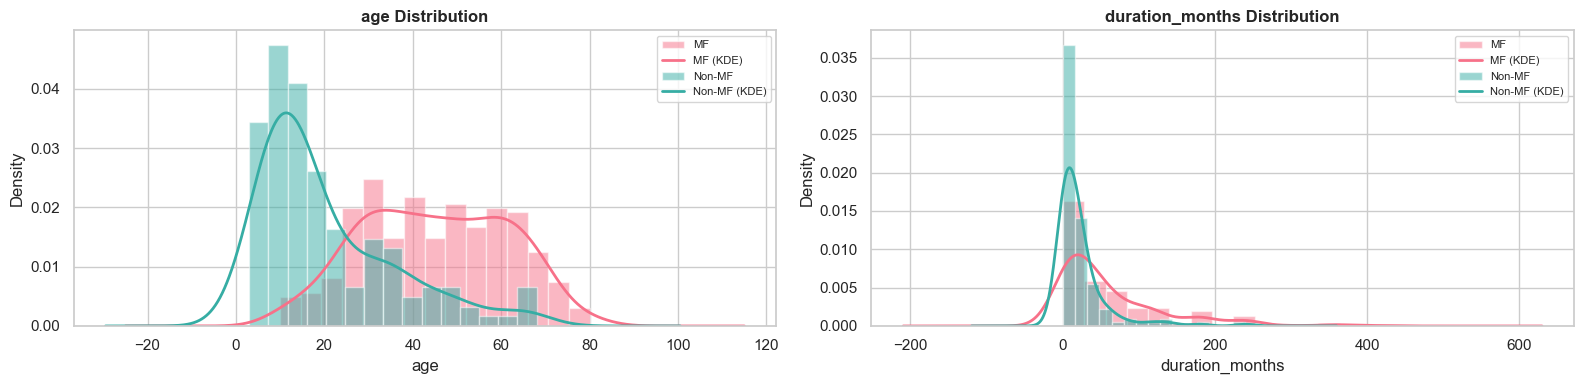

In [ ]:
# Define continuous variables to analyze
CONTINUOUS_VARS = ['age', 'duration_months']

# Dictionary to store results for continuous variables
continuous_results = []

# Create a figure for all continuous variable distributions
fig, axes = plt.subplots(1, len(CONTINUOUS_VARS), figsize=(16, 4))
if len(CONTINUOUS_VARS) == 1:
    axes = [axes]  # Ensure axes is iterable even with 1 subplot

print("\n" + "="*80)
print("CONTINUOUS VARIABLES ANALYSIS")
print("="*80)

for idx, var in enumerate(CONTINUOUS_VARS):
    print(f"\n[{var.upper()}]")
    print("-" * 60)
    
    # Get valid data for each class
    data_mf = df[df['diagnosis_target'] == 1][var].dropna()
    data_non_mf = df[df['diagnosis_target'] == 0][var].dropna()
    
    print(f"  MF (n={len(data_mf)}):        mean={data_mf.mean():.2f} ± {data_mf.std():.2f}")
    print(f"  Non-MF (n={len(data_non_mf)}): mean={data_non_mf.mean():.2f} ± {data_non_mf.std():.2f}")
    
    # Plot: Histogram + KDE by diagnosis
    ax = axes[idx]
    for target, label, color in [(1, 'MF', COLORS[0]), (0, 'Non-MF', COLORS[1])]:
        data = df[df['diagnosis_target'] == target][var].dropna()
        ax.hist(data, bins=15, alpha=0.5, label=label, color=color, edgecolor='white', density=True)
        data.plot.kde(ax=ax, color=color, linewidth=2, label=f'{label} (KDE)')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.set_title(f'{var} Distribution', fontweight='bold')
    ax.legend(fontsize=8)
    
    # Normality test (Shapiro-Wilk)
    if len(data_mf) > 2:
        stat_mf, p_mf = shapiro(data_mf)
        is_normal_mf = p_mf > 0.1
    else:
        is_normal_mf = False
        p_mf = np.nan
    
    if len(data_non_mf) > 2:
        stat_nmf, p_nmf = shapiro(data_non_mf)
        is_normal_nmf = p_nmf > 0.1
    else:
        is_normal_nmf = False
        p_nmf = np.nan
    
    print(f"  Shapiro-Wilk Test (α=0.1):")
    print(f"    MF:        p={p_mf:.4f} → {'Normal' if is_normal_mf else 'Skewed'}")
    print(f"    Non-MF:    p={p_nmf:.4f} → {'Normal' if is_normal_nmf else 'Skewed'}")
    
    # Determine appropriate statistical test
    is_skewed = not (is_normal_mf and is_normal_nmf)
    
    if is_skewed or len(data_mf) < 3 or len(data_non_mf) < 3:
        # Use Mann-Whitney U test (non-parametric)
        if len(data_mf) > 0 and len(data_non_mf) > 0:
            stat_test, p_value = mannwhitneyu(data_mf, data_non_mf, alternative='two-sided')
            test_used = 'Mann-Whitney U'
        else:
            test_used = 'N/A'
            p_value = np.nan
    else:
        # Use Welch's t-test (assumes equal variances not required)
        if len(data_mf) > 0 and len(data_non_mf) > 0:
            stat_test, p_value = ttest_ind(data_mf, data_non_mf, equal_var=False)
            test_used = "Welch's t-test"
        else:
            test_used = 'N/A'
            p_value = np.nan
    
    print(f"  Statistical Test: {test_used}")
    print(f"  P-Value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"  ✓ SIGNIFICANT (p < 0.05)")
    else:
        print(f"  ✗ Not significant (p ≥ 0.05)")
    
    # Store result
    continuous_results.append({
        'Feature': var,
        'Type': 'Continuous',
        'Is_Skewed': is_skewed,
        'Test_Used': test_used,
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

plt.tight_layout()
plt.savefig('eda_continuous_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — Categorical Variables: Frequency & Chi-Squared Testing

For each categorical variable:
1. **Distribution Plot:** Grouped bar chart showing counts by diagnosis
2. **Chi-Squared Test:** Test for independence between feature and diagnosis
3. **Results:** P-value and decision (handle expected frequencies < 5)


CATEGORICAL VARIABLES ANALYSIS

[MACULES]
------------------------------------------------------------
  Valid samples: 499
  Categories: 2
  Chi-Squared Test:
    χ²=269.2003, dof=1, p=0.0000
  P-Value: 0.0000
  ✓ SIGNIFICANT (p < 0.05)

[BX1_MORPH]
------------------------------------------------------------
  Valid samples: 499
  Categories: 7
  Chi-Squared Test:
    χ²=235.3493, dof=6, p=0.0000 (⚠ 4/14 cells have expected freq < 5)
  P-Value: 0.0000
  ✓ SIGNIFICANT (p < 0.05)

[PAPULES]
------------------------------------------------------------
  Valid samples: 499
  Categories: 2
  Chi-Squared Test:
    χ²=186.3539, dof=1, p=0.0000
  P-Value: 0.0000
  ✓ SIGNIFICANT (p < 0.05)

[COLOR]
------------------------------------------------------------
  Valid samples: 498
  Categories: 5
  Chi-Squared Test:
    χ²=135.9365, dof=4, p=0.0000 (⚠ 2/10 cells have expected freq < 5)
  P-Value: 0.0000
  ✓ SIGNIFICANT (p < 0.05)

[PATCH]
-------------------------------------------------------

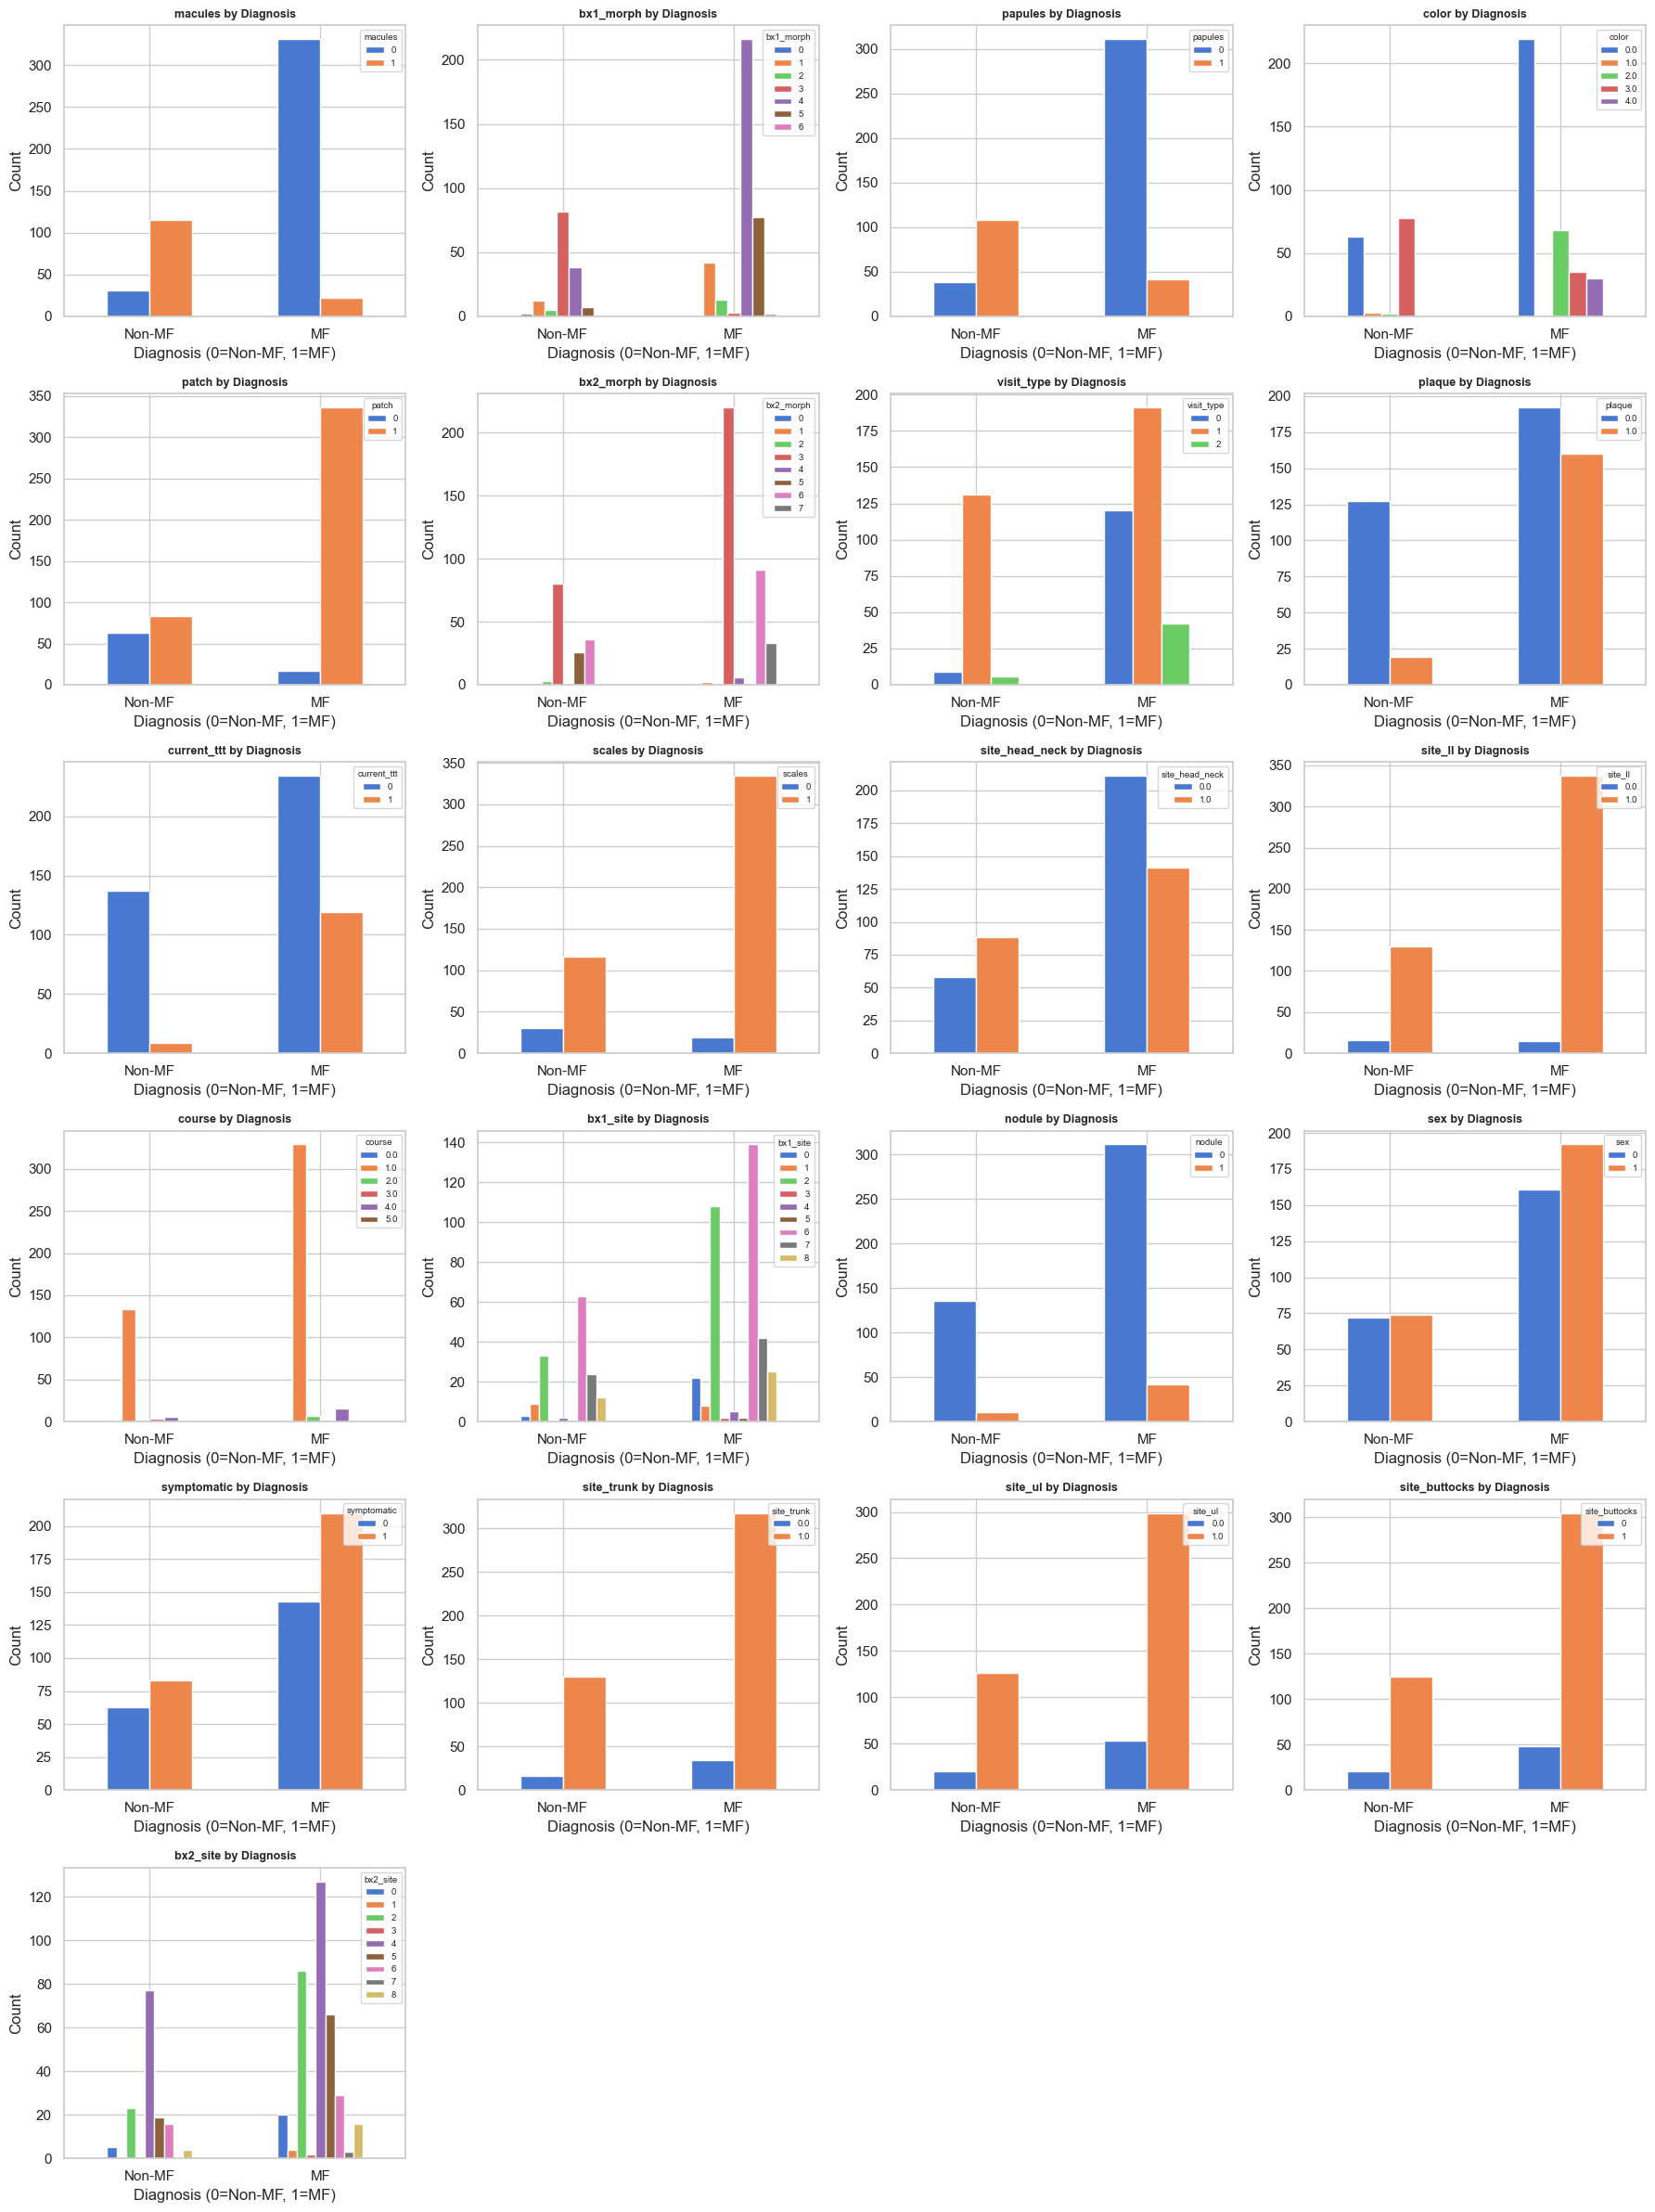

In [ ]:
# Define categorical variables to analyze
CATEGORICAL_VARS = [
    'macules', 'bx1_morph', 'papules', 'color', 'patch', 'bx2_morph',
    'visit_type', 'plaque', 'current_ttt', 'scales', 'site_head_neck',
    'site_ll', 'course', 'bx1_site', 'nodule', 'sex', 'symptomatic',
    'site_trunk', 'site_ul', 'site_buttocks', 'bx2_site'
]

# Filter to only existing columns
CATEGORICAL_VARS = [v for v in CATEGORICAL_VARS if v in df.columns]

# Dictionary to store results for categorical variables
categorical_results = []

print("\n" + "="*80)
print("CATEGORICAL VARIABLES ANALYSIS")
print("="*80)

# Create subplots for categorical variables (arrange in grid)
n_vars = len(CATEGORICAL_VARS)
n_cols = 4
n_rows = (n_vars + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()  # Flatten to 1D for easier indexing

for idx, var in enumerate(CATEGORICAL_VARS):
    print(f"\n[{var.upper()}]")
    print("-" * 60)
    
    # Create contingency table
    contingency = pd.crosstab(df[var], df['diagnosis_target'])
    
    # Handle cases with very few samples
    n_valid = contingency.sum().sum()
    print(f"  Valid samples: {n_valid}")
    print(f"  Categories: {len(contingency)}")
    
    # Chi-Squared test
    # Note: Chi-squared test assumes expected frequencies ≥ 5 in each cell.
    # If expected frequencies < 5, results may be unreliable.
    if contingency.shape[0] > 1 and n_valid > 2:
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        
        # Check for expected frequencies < 5
        low_freq_cells = np.sum(expected < 5)
        total_cells = expected.size
        low_freq_pct = (low_freq_cells / total_cells) * 100
        
        test_used = 'Chi-Squared'
        warning = ""
        if low_freq_cells > 0:
            warning = f" (⚠ {low_freq_cells}/{total_cells} cells have expected freq < 5)"
        
        print(f"  Chi-Squared Test:")
        print(f"    χ²={chi2:.4f}, dof={dof}, p={p_value:.4f}{warning}")
    else:
        test_used = 'N/A'
        p_value = np.nan
        print(f"  Chi-Squared Test: N/A (insufficient categories or samples)")
    
    print(f"  P-Value: {p_value:.4f}")
    
    if not np.isnan(p_value):
        if p_value < 0.05:
            print(f"  ✓ SIGNIFICANT (p < 0.05)")
        else:
            print(f"  ✗ Not significant (p ≥ 0.05)")
    
    # Plot: Grouped bar chart
    ax = axes[idx]
    contingency.T.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(contingency)), edgecolor='white')
    ax.set_xlabel('Diagnosis (0=Non-MF, 1=MF)')
    ax.set_ylabel('Count')
    ax.set_title(f'{var} by Diagnosis', fontweight='bold', fontsize=9)
    ax.legend(title=var, fontsize=7, title_fontsize=7, loc='upper right')
    ax.set_xticklabels(['Non-MF', 'MF'], rotation=0)
    
    # Store result
    categorical_results.append({
        'Feature': var,
        'Type': 'Categorical',
        'N_Valid': n_valid,
        'N_Categories': len(contingency),
        'Test_Used': test_used,
        'P_Value': p_value,
        'Significant': 'Yes' if (not np.isnan(p_value) and p_value < 0.05) else 'No'
    })

# Remove empty subplots
for idx in range(len(CATEGORICAL_VARS), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('eda_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Summary Results

Combined DataFrame of all statistical tests, sorted by p-value.

In [14]:
# Combine results from continuous and categorical variables
all_results = pd.DataFrame(continuous_results + categorical_results)

# Sort by p-value (most significant first)
all_results = all_results.sort_values('P_Value').reset_index(drop=True)

# Round p-values for display
all_results['P_Value'] = all_results['P_Value'].round(4)

print("\n" + "="*80)
print("SUMMARY: ALL FEATURES RANKED BY P-VALUE (ASCENDING)")
print("="*80)
print(all_results.to_string(index=False))

# Count significant features
n_significant = (all_results['Significant'] == 'Yes').sum()
print(f"\n\nSIGNIFICANT FEATURES (p < 0.05): {n_significant}/{len(all_results)}")
print("-" * 80)


SUMMARY: ALL FEATURES RANKED BY P-VALUE (ASCENDING)
        Feature        Type Is_Skewed      Test_Used  P_Value Significant  N_Valid  N_Categories
        macules Categorical       NaN    Chi-Squared   0.0000         Yes    499.0           2.0
      bx1_morph Categorical       NaN    Chi-Squared   0.0000         Yes    499.0           7.0
        papules Categorical       NaN    Chi-Squared   0.0000         Yes    499.0           2.0
            age  Continuous      True Mann-Whitney U   0.0000         Yes      NaN           NaN
          color Categorical       NaN    Chi-Squared   0.0000         Yes    498.0           5.0
          patch Categorical       NaN    Chi-Squared   0.0000         Yes    499.0           2.0
      bx2_morph Categorical       NaN    Chi-Squared   0.0000         Yes    499.0           8.0
     visit_type Categorical       NaN    Chi-Squared   0.0000         Yes    499.0           3.0
duration_months  Continuous      True Mann-Whitney U   0.0000         Yes 

In [15]:
# Display significant features only
significant_features = all_results[all_results['Significant'] == 'Yes']
if len(significant_features) > 0:
    print(significant_features[['Feature', 'Type', 'Test_Used', 'P_Value']].to_string(index=False))
else:
    print("No significant features found at α=0.05")

        Feature        Type      Test_Used  P_Value
        macules Categorical    Chi-Squared   0.0000
      bx1_morph Categorical    Chi-Squared   0.0000
        papules Categorical    Chi-Squared   0.0000
            age  Continuous Mann-Whitney U   0.0000
          color Categorical    Chi-Squared   0.0000
          patch Categorical    Chi-Squared   0.0000
      bx2_morph Categorical    Chi-Squared   0.0000
     visit_type Categorical    Chi-Squared   0.0000
duration_months  Continuous Mann-Whitney U   0.0000
         plaque Categorical    Chi-Squared   0.0000
    current_ttt Categorical    Chi-Squared   0.0000
         scales Categorical    Chi-Squared   0.0000
 site_head_neck Categorical    Chi-Squared   0.0001
        site_ll Categorical    Chi-Squared   0.0090
         course Categorical    Chi-Squared   0.0100
       bx2_site Categorical    Chi-Squared   0.0327



Results saved to: EDA_Statistical_Results.csv


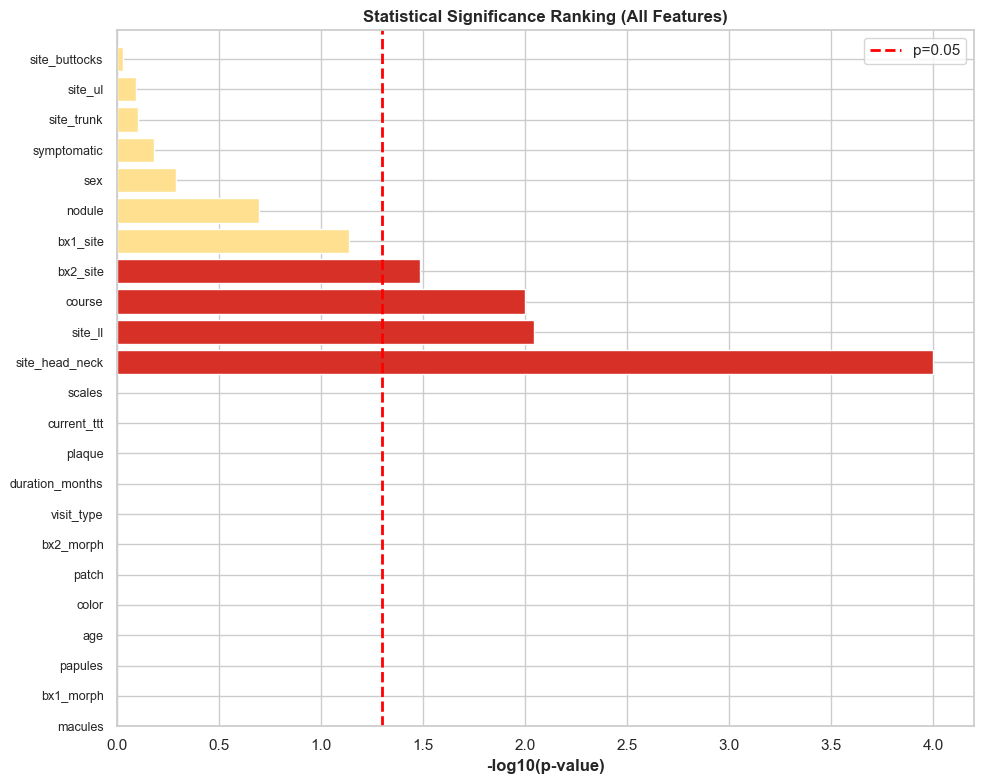

Visualization saved to: eda_pvalue_ranking.png


In [16]:
# Save results to CSV
all_results.to_csv('EDA_Statistical_Results.csv', index=False)
print('\nResults saved to: EDA_Statistical_Results.csv')

# Create visualization of p-values
fig, ax = plt.subplots(figsize=(10, 8))
significant = all_results['P_Value'] < 0.05
colors = ['#d73027' if s else '#fee090' for s in significant]
ax.barh(range(len(all_results)), -np.log10(all_results['P_Value']), color=colors, edgecolor='white')
ax.set_yticks(range(len(all_results)))
ax.set_yticklabels(all_results['Feature'], fontsize=9)
ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
ax.set_xlabel('-log10(p-value)', fontweight='bold')
ax.set_title('Statistical Significance Ranking (All Features)', fontweight='bold', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('eda_pvalue_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print('Visualization saved to: eda_pvalue_ranking.png')